In [1]:
!unzip arechive.zip
! unzip archive.zip

unzip:  cannot find or open arechive.zip, arechive.zip.zip or arechive.zip.ZIP.
Archive:  archive.zip
  inflating: Hotel Reservations.csv  


In [4]:
import pandas as pd

df = pd.read_csv("Hotel Reservations.csv")

df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [5]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nTarget values:")
print(df["booking_status"].value_counts())

Dataset shape: (36275, 19)

Columns:
['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'booking_status']

Target values:
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


In [6]:
# معلومات عن البيانات
df.info()

# القيم المفقودة
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [7]:
# حذف Booking_ID لأنه مجرد معرف للحجز
df = df.drop(columns=['Booking_ID'])

# تحويل الهدف إلى أرقام
df['booking_status'] = df['booking_status'].map({
    'Not_Canceled': 0,
    'Canceled': 1
})

print(df['booking_status'].value_counts())
print("\nNew shape:", df.shape)

booking_status
0    24390
1    11885
Name: count, dtype: int64

New shape: (36275, 18)


In [8]:
# فصل المدخلات عن الهدف
X = df.drop(columns=['booking_status'])
y = df['booking_status']

# معرفة الأعمدة النصية والرقمية
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("X shape:", X.shape)
print("y shape:", y.shape)

Categorical columns: ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
Numeric columns: ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']
X shape: (36275, 17)
y shape: (36275,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True))

print("\nTest target:")
print(y_test.value_counts(normalize=True))

Training data: (29020, 17)
Test data: (7255, 17)

Training target:
booking_status
0    0.672364
1    0.327636
Name: proportion, dtype: float64

Test target:
booking_status
0    0.672364
1    0.327636
Name: proportion, dtype: float64


In [10]:
# تجهيز البيانات وتدريب XGBoost

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier

# تجهيز الأعمدة النصية
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# الموديل
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

# Pipeline لمنع تسرب البيانات
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# التدريب
pipeline.fit(X_train, y_train)

# التوقع
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# النتائج
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8882150241212956
Precision: 0.859504132231405
Recall: 0.7875473285654186
ROC-AUC: 0.9477939899298026
PR-AUC: 0.9126240084798493

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4878
           1       0.86      0.79      0.82      2377

    accuracy                           0.89      7255
   macro avg       0.88      0.86      0.87      7255
weighted avg       0.89      0.89      0.89      7255


Confusion Matrix:
[[4572  306]
 [ 505 1872]]


In [11]:
# تجهيز البيانات وتدريب XGBoost

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier

# تجهيز الأعمدة النصية
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# الموديل
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

# Pipeline لمنع تسرب البيانات
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# التدريب
pipeline.fit(X_train, y_train)

# التوقع
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# النتائج
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8882150241212956
Precision: 0.859504132231405
Recall: 0.7875473285654186
ROC-AUC: 0.9477939899298026
PR-AUC: 0.9126240084798493

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4878
           1       0.86      0.79      0.82      2377

    accuracy                           0.89      7255
   macro avg       0.88      0.86      0.87      7255
weighted avg       0.89      0.89      0.89      7255


Confusion Matrix:
[[4572  306]
 [ 505 1872]]


Development data: (29020, 17)
Final holdout: (7255, 17)
Positive class rate: 0.32763611302549966

===== Fold Results =====
   Fold   ROC_AUC    PR_AUC
0     1  0.943101  0.905372
1     2  0.950204  0.918303
2     3  0.949491  0.918338
3     4  0.949156  0.916640
4     5  0.954414  0.925574

===== Mean ± STD =====
ROC-AUC: 0.9493 ± 0.004
PR-AUC: 0.9168 ± 0.0073

===== OOF Evaluation =====
Precision: 0.858
Recall: 0.7904

Confusion Matrix:
[[18268  1244]
 [ 1993  7515]]


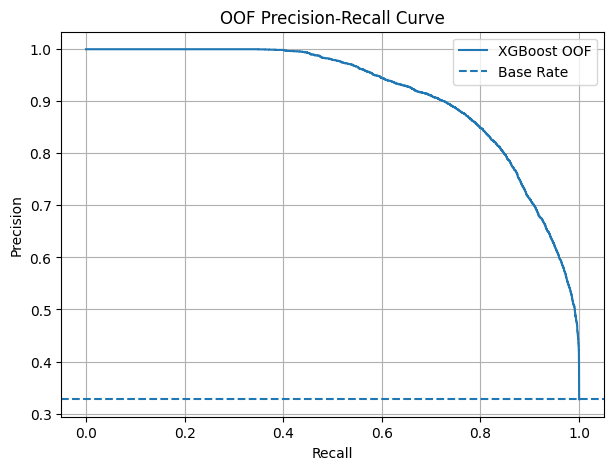


Done ✅


In [12]:
# ==========================================
# Validation + OOF Baseline
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    confusion_matrix,
    precision_recall_curve
)
from xgboost import XGBClassifier

# إنشاء مجلدات لحفظ الصور والنتائج
os.makedirs("images", exist_ok=True)
os.makedirs("results", exist_ok=True)

# ------------------------------------------
# 1) إنشاء Final Holdout جديد
# ------------------------------------------
# هذا الجزء نخليه للنهاية ولا نستخدمه أثناء تحسين الموديل
X_dev, X_final, y_dev, y_final = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=2026,
    stratify=y
)

print("Development data:", X_dev.shape)
print("Final holdout:", X_final.shape)
print("Positive class rate:", y_dev.mean())

# ------------------------------------------
# 2) 5-Fold Stratified Cross Validation
# ------------------------------------------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_prob = np.zeros(len(X_dev))
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_dev, y_dev), 1):

    X_tr = X_dev.iloc[train_idx]
    X_val = X_dev.iloc[val_idx]

    y_tr = y_dev.iloc[train_idx]
    y_val = y_dev.iloc[val_idx]

    # تجهيز البيانات داخل كل Fold لمنع Data Leakage
    preprocessor_fold = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_cols
            )
        ],
        remainder="passthrough"
    )

    X_tr_transformed = preprocessor_fold.fit_transform(X_tr)
    X_val_transformed = preprocessor_fold.transform(X_val)

    # نموذج XGBoost
    model_fold = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        early_stopping_rounds=50
    )

    model_fold.fit(
        X_tr_transformed,
        y_tr,
        eval_set=[(X_val_transformed, y_val)],
        verbose=False
    )

    # احتمالات التنبؤ
    val_prob = model_fold.predict_proba(
        X_val_transformed
    )[:, 1]

    oof_prob[val_idx] = val_prob

    # نتائج كل Fold
    fold_results.append({
        "Fold": fold,
        "ROC_AUC": roc_auc_score(y_val, val_prob),
        "PR_AUC": average_precision_score(y_val, val_prob)
    })

# ------------------------------------------
# 3) عرض نتائج Cross Validation
# ------------------------------------------
cv_results = pd.DataFrame(fold_results)

print("\n===== Fold Results =====")
print(cv_results)

print("\n===== Mean ± STD =====")

print(
    "ROC-AUC:",
    round(cv_results["ROC_AUC"].mean(), 4),
    "±",
    round(cv_results["ROC_AUC"].std(), 4)
)

print(
    "PR-AUC:",
    round(cv_results["PR_AUC"].mean(), 4),
    "±",
    round(cv_results["PR_AUC"].std(), 4)
)

# ------------------------------------------
# 4) OOF Evaluation عند Threshold = 0.5
# ------------------------------------------
oof_pred = (oof_prob >= 0.5).astype(int)

print("\n===== OOF Evaluation =====")

print(
    "Precision:",
    round(precision_score(y_dev, oof_pred), 4)
)

print(
    "Recall:",
    round(recall_score(y_dev, oof_pred), 4)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_dev, oof_pred))

# ------------------------------------------
# 5) Precision-Recall Curve
# ------------------------------------------
precision_values, recall_values, thresholds = precision_recall_curve(
    y_dev,
    oof_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values,
    label="XGBoost OOF"
)

plt.axhline(
    y=y_dev.mean(),
    linestyle="--",
    label="Base Rate"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("OOF Precision-Recall Curve")
plt.legend()
plt.grid()

plt.savefig(
    "images/pr_curve.png",
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------
# 6) حفظ النتائج
# ------------------------------------------
cv_results.to_csv(
    "results/cv_baseline.csv",
    index=False
)

print("\nDone ✅")

Negative class: 19512
Positive class: 9508
Positive class rate: 0.3276

===== Baseline at Threshold 0.5 =====
Threshold : 0.5
Precision : 0.858
Recall : 0.7904
F1 : 0.8228
ROC_AUC : 0.9492
PR_AUC : 0.9168

===== Best Threshold using OOF =====
Best Threshold: 0.39
Precision: 0.8202
Recall: 0.8307
F1: 0.8254
Flagged Count: 9629
Flagged Rate: 0.3318

Confusion Matrix:
[[17781  1731]
 [ 1610  7898]]

True Negatives: 17781
False Positives: 1731
False Negatives: 1610
True Positives: 7898


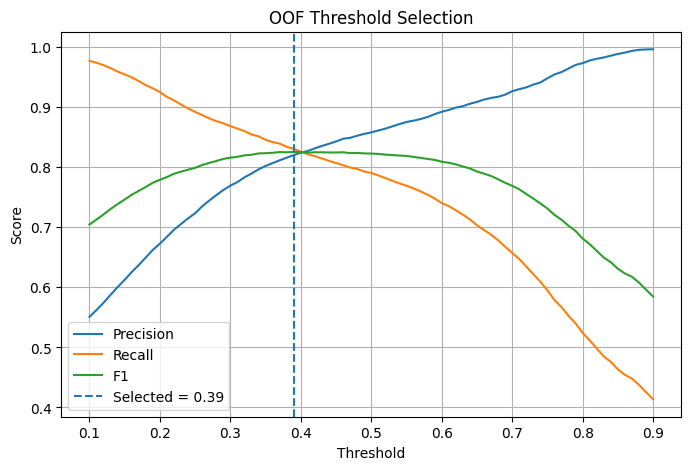


Threshold analysis saved ✅


In [13]:
# ==========================================
# Imbalance + Threshold Selection
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------
# 1) Class Balance
# ------------------------------------------

negative_count = (y_dev == 0).sum()
positive_count = (y_dev == 1).sum()

print("Negative class:", negative_count)
print("Positive class:", positive_count)

print(
    "Positive class rate:",
    round(positive_count / len(y_dev), 4)
)

# ------------------------------------------
# 2) Baseline performance at threshold = 0.5
# ------------------------------------------

baseline_pred = (oof_prob >= 0.5).astype(int)

baseline_results = {
    "Threshold": 0.5,
    "Precision": precision_score(y_dev, baseline_pred),
    "Recall": recall_score(y_dev, baseline_pred),
    "F1": f1_score(y_dev, baseline_pred),
    "ROC_AUC": roc_auc_score(y_dev, oof_prob),
    "PR_AUC": average_precision_score(y_dev, oof_prob)
}

print("\n===== Baseline at Threshold 0.5 =====")

for key, value in baseline_results.items():
    print(key, ":", round(value, 4))

# ------------------------------------------
# 3) Threshold Sweep
# نختار Threshold باستخدام OOF فقط
# ------------------------------------------

threshold_values = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in threshold_values:

    pred = (oof_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_dev, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_dev, pred, zero_division=0
        ),
        "F1": f1_score(
            y_dev, pred, zero_division=0
        ),
        "Flagged_Count": pred.sum(),
        "Flagged_Rate": pred.mean()
    })

threshold_df = pd.DataFrame(threshold_results)

# ------------------------------------------
# 4) اختيار أفضل Threshold حسب F1
# ------------------------------------------

best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = float(best_row["Threshold"])

print("\n===== Best Threshold using OOF =====")

print(
    "Best Threshold:",
    round(best_threshold, 2)
)

print(
    "Precision:",
    round(best_row["Precision"], 4)
)

print(
    "Recall:",
    round(best_row["Recall"], 4)
)

print(
    "F1:",
    round(best_row["F1"], 4)
)

print(
    "Flagged Count:",
    int(best_row["Flagged_Count"])
)

print(
    "Flagged Rate:",
    round(best_row["Flagged_Rate"], 4)
)

# ------------------------------------------
# 5) Confusion Matrix عند Threshold المختار
# ------------------------------------------

best_pred = (
    oof_prob >= best_threshold
).astype(int)

cm = confusion_matrix(y_dev, best_pred)

print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

# ------------------------------------------
# 6) Threshold Curve
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("OOF Threshold Selection")
plt.legend()
plt.grid()

plt.savefig(
    "images/threshold_curve.png",
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------
# 7) حفظ النتائج
# ------------------------------------------

threshold_df.to_csv(
    "results/threshold_results.csv",
    index=False
)

print("\nThreshold analysis saved ✅")

In [14]:
# ==========================================
# Class Weighting Comparison
# ==========================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score
)
from xgboost import XGBClassifier

# حساب وزن الفئة الموجبة
negative_count = (y_dev == 0).sum()
positive_count = (y_dev == 1).sum()

scale_pos_weight = negative_count / positive_count

print("scale_pos_weight =", round(scale_pos_weight, 4))

# نفس الـ CV المستخدم قبل
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

weighted_oof_prob = np.zeros(len(X_dev))
weighted_fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_dev, y_dev), 1):

    X_tr = X_dev.iloc[train_idx]
    X_val = X_dev.iloc[val_idx]

    y_tr = y_dev.iloc[train_idx]
    y_val = y_dev.iloc[val_idx]

    # Preprocessing داخل كل Fold
    preprocessor_fold = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_cols
            )
        ],
        remainder="passthrough"
    )

    X_tr_t = preprocessor_fold.fit_transform(X_tr)
    X_val_t = preprocessor_fold.transform(X_val)

    # XGBoost مع Class Weighting
    weighted_model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        early_stopping_rounds=50,
        scale_pos_weight=scale_pos_weight
    )

    weighted_model.fit(
        X_tr_t,
        y_tr,
        eval_set=[(X_val_t, y_val)],
        verbose=False
    )

    val_prob = weighted_model.predict_proba(X_val_t)[:, 1]
    weighted_oof_prob[val_idx] = val_prob

    weighted_fold_results.append({
        "Fold": fold,
        "ROC_AUC": roc_auc_score(y_val, val_prob),
        "PR_AUC": average_precision_score(y_val, val_prob)
    })

# ==========================================
# نتائج الموديل الموزون
# ==========================================

weighted_cv_results = pd.DataFrame(weighted_fold_results)

weighted_pred_05 = (weighted_oof_prob >= 0.5).astype(int)

print("\n===== Weighted Model =====")

print(
    "ROC-AUC:",
    round(weighted_cv_results["ROC_AUC"].mean(), 4),
    "±",
    round(weighted_cv_results["ROC_AUC"].std(), 4)
)

print(
    "PR-AUC:",
    round(weighted_cv_results["PR_AUC"].mean(), 4),
    "±",
    round(weighted_cv_results["PR_AUC"].std(), 4)
)

print(
    "Precision:",
    round(
        precision_score(y_dev, weighted_pred_05),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(y_dev, weighted_pred_05),
        4
    )
)

print(
    "Mean predicted probability:",
    round(weighted_oof_prob.mean(), 4)
)

# ==========================================
# مقارنة Baseline vs Weighted
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Class Weighted"
    ],
    "ROC_AUC": [
        cv_results["ROC_AUC"].mean(),
        weighted_cv_results["ROC_AUC"].mean()
    ],
    "PR_AUC": [
        cv_results["PR_AUC"].mean(),
        weighted_cv_results["PR_AUC"].mean()
    ],
    "Precision_at_0.5": [
        precision_score(
            y_dev,
            (oof_prob >= 0.5).astype(int)
        ),
        precision_score(
            y_dev,
            weighted_pred_05
        )
    ],
    "Recall_at_0.5": [
        recall_score(
            y_dev,
            (oof_prob >= 0.5).astype(int)
        ),
        recall_score(
            y_dev,
            weighted_pred_05
        )
    ],
    "Mean_Predicted_Probability": [
        oof_prob.mean(),
        weighted_oof_prob.mean()
    ]
})

print("\n===== Comparison =====")
print(comparison)

comparison.to_csv(
    "results/imbalance_comparison.csv",
    index=False
)

weighted_cv_results.to_csv(
    "results/weighted_cv_results.csv",
    index=False
)

print("\nImbalance comparison saved ✅")

scale_pos_weight = 2.0522

===== Weighted Model =====
ROC-AUC: 0.9497 ± 0.0038
PR-AUC: 0.9164 ± 0.007
Precision: 0.7986
Recall: 0.8508
Mean predicted probability: 0.3856

===== Comparison =====
            Model   ROC_AUC    PR_AUC  Precision_at_0.5  Recall_at_0.5  \
0        Baseline  0.949273  0.916845          0.857975       0.790387   
1  Class Weighted  0.949705  0.916378          0.798598       0.850757   

   Mean_Predicted_Probability  
0                    0.327061  
1                    0.385640  

Imbalance comparison saved ✅


In [15]:
# ==========================================
# Optuna Hyperparameter Tuning
# ==========================================

!pip -q install optuna

import optuna
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

# نفس 5-Fold CV
optuna_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def objective(trial):

    params = {
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.10, log=True
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 7
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 10, 120
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 0.01, 10.0, log=True
        )
    }

    fold_scores = []

    for train_idx, val_idx in optuna_cv.split(X_dev, y_dev):

        X_tr = X_dev.iloc[train_idx]
        X_val = X_dev.iloc[val_idx]

        y_tr = y_dev.iloc[train_idx]
        y_val = y_dev.iloc[val_idx]

        # Preprocessing داخل كل Fold
        prep = ColumnTransformer(
            transformers=[
                (
                    "cat",
                    OneHotEncoder(handle_unknown="ignore"),
                    categorical_cols
                )
            ],
            remainder="passthrough"
        )

        X_tr_t = prep.fit_transform(X_tr)
        X_val_t = prep.transform(X_val)

        model = XGBClassifier(
            n_estimators=1000,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss",
            early_stopping_rounds=50,
            **params
        )

        model.fit(
            X_tr_t,
            y_tr,
            eval_set=[(X_val_t, y_val)],
            verbose=False
        )

        val_prob = model.predict_proba(X_val_t)[:, 1]

        score = average_precision_score(
            y_val,
            val_prob
        )

        fold_scores.append(score)

    return np.mean(fold_scores)


# ==========================================
# تشغيل Optuna
# ==========================================

sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

study.optimize(
    objective,
    n_trials=10
)

# ==========================================
# النتائج
# ==========================================

print("\n===== Optuna Results =====")

print(
    "Best PR-AUC:",
    round(study.best_value, 4)
)

print("\nBest Parameters:")

for key, value in study.best_params.items():
    print(key, ":", value)

baseline_pr_auc = cv_results["PR_AUC"].mean()

improvement = study.best_value - baseline_pr_auc

print(
    "\nBaseline PR-AUC:",
    round(baseline_pr_auc, 4)
)

print(
    "Tuned PR-AUC:",
    round(study.best_value, 4)
)

print(
    "Improvement:",
    round(improvement, 4)
)

# حفظ النتائج
trials_df = study.trials_dataframe()

trials_df.to_csv(
    "results/optuna_trials.csv",
    index=False
)

pd.DataFrame(
    [study.best_params]
).to_csv(
    "results/best_params.csv",
    index=False
)

best_params = study.best_params

print("\nOptuna results saved ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 13.0 MB/s eta 0:00:00


[I 2026-09-08 20:20:47,161] A new study created in memory with name: no-name-5c507bef-d577-4fd4-be8c-0982b77ce158
[I 2026-09-08 20:21:14,145] Trial 0 finished with value: 0.8795344567844264 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 7, 'min_child_weight': 91, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_lambda': 0.029375384576328288}. Best is trial 0 with value: 0.8795344567844264.
[I 2026-09-08 20:21:42,860] Trial 1 finished with value: 0.873418155715745 and parameters: {'learning_rate': 0.011430983876313222, 'max_depth': 7, 'min_child_weight': 76, 'subsample': 0.8832290311184181, 'colsample_bytree': 0.608233797718321, 'reg_lambda': 8.123245085588687}. Best is trial 0 with value: 0.8795344567844264.
[I 2026-09-08 20:22:06,982] Trial 2 finished with value: 0.8988592885717294 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'min_child_weight': 30, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.72169


===== Optuna Results =====
Best PR-AUC: 0.9122

Best Parameters:
learning_rate : 0.03961867790406585
max_depth : 7
min_child_weight : 19
subsample : 0.6783931449676581
colsample_bytree : 0.6180909155642152
reg_lambda : 0.09462175356461491

Baseline PR-AUC: 0.9168
Tuned PR-AUC: 0.9122
Improvement: -0.0046

Optuna results saved ✅


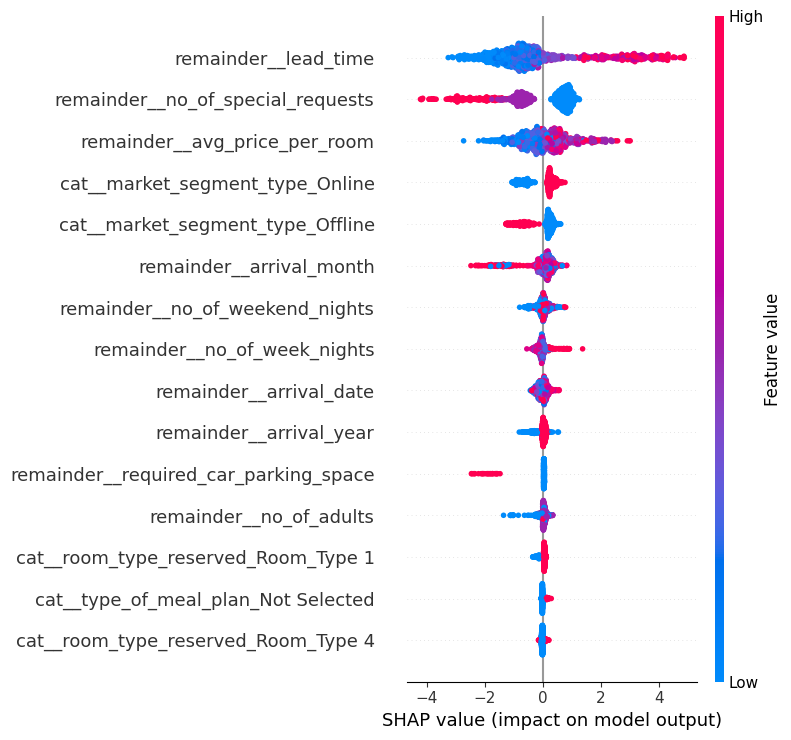

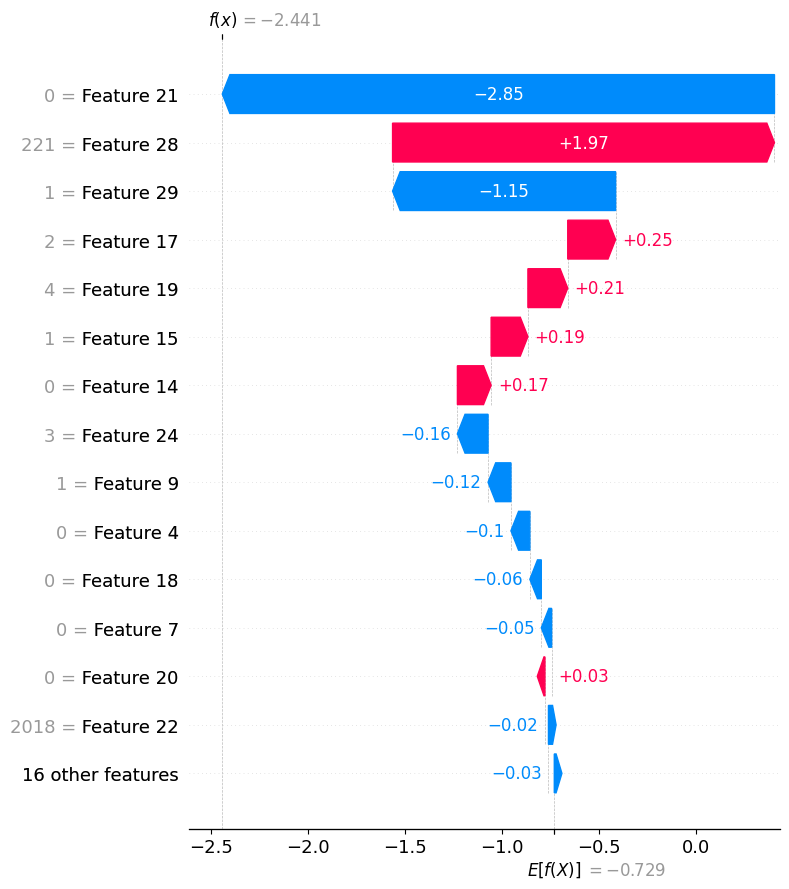

SHAP completed and images saved ✅


In [16]:
# ==========================================
# SHAP - Model Interpretability
# ==========================================

!pip -q install shap

import shap
import matplotlib.pyplot as plt
import os
from xgboost import XGBClassifier

os.makedirs("images", exist_ok=True)

# Preprocess development data
shap_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

X_dev_transformed = shap_preprocessor.fit_transform(X_dev)

# Train model using the best Optuna parameters
shap_model = XGBClassifier(
    **best_params,
    n_estimators=500,
    random_state=42,
    eval_metric="logloss"
)

shap_model.fit(X_dev_transformed, y_dev)

# Feature names
feature_names = shap_preprocessor.get_feature_names_out()

# Use a sample to make SHAP faster
sample_size = min(1000, X_dev_transformed.shape[0])
X_shap = X_dev_transformed[:sample_size]

# SHAP values
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer(X_shap)

# Global SHAP summary
plt.figure()
shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=feature_names,
    show=False,
    max_display=15
)
plt.tight_layout()
plt.savefig("images/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Local explanation for one reservation
shap.plots.waterfall(shap_values[0], max_display=15, show=False)
plt.tight_layout()
plt.savefig("images/shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

print("SHAP completed and images saved ✅")

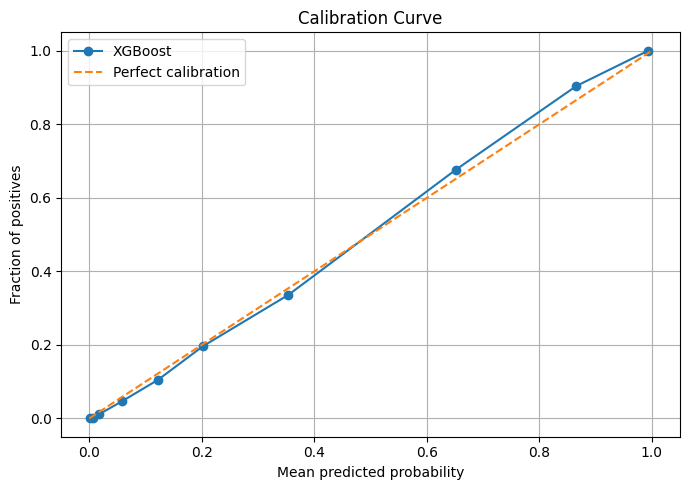

Brier Score: 0.0818
Calibration completed ✅


In [18]:
# ==========================================
# Calibration
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(
    y_dev,
    oof_prob,
    n_bins=10,
    strategy="quantile"
)

brier = brier_score_loss(y_dev, oof_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "images/calibration_curve.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Brier Score:", round(brier, 4))
print("Calibration completed ✅")

In [19]:
# ==========================================
# FINAL HOLDOUT EVALUATION
# ==========================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# تجهيز بيانات الـ Final Holdout
X_dev_t = shap_preprocessor.fit_transform(X_dev)
X_final_t = shap_preprocessor.transform(X_final)

# تدريب النموذج النهائي بأفضل إعدادات Optuna
final_model = XGBClassifier(
    **best_params,
    n_estimators=500,
    random_state=42,
    eval_metric="logloss"
)

final_model.fit(X_dev_t, y_dev)

# التنبؤ على الـ Final Holdout لأول مرة
final_prob = final_model.predict_proba(X_final_t)[:, 1]

# استخدام الـ threshold الذي اخترناه من OOF
final_pred = (final_prob >= best_threshold).astype(int)

print("===== FINAL HOLDOUT RESULTS =====")
print("ROC-AUC:", round(roc_auc_score(y_final, final_prob), 4))
print("PR-AUC:", round(average_precision_score(y_final, final_prob), 4))
print("Precision:", round(precision_score(y_final, final_pred), 4))
print("Recall:", round(recall_score(y_final, final_pred), 4))
print("F1:", round(f1_score(y_final, final_pred), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_final, final_pred))

print("\nFinal holdout evaluation completed ✅")

===== FINAL HOLDOUT RESULTS =====
ROC-AUC: 0.9463
PR-AUC: 0.9138
Precision: 0.8178
Recall: 0.8212
F1: 0.8195

Confusion Matrix:
[[4443  435]
 [ 425 1952]]

Final holdout evaluation completed ✅


In [20]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("images", exist_ok=True)
os.makedirs("results", exist_ok=True)

readme = """# Hotel Reservation Cancellation Prediction

## Project Overview
This project predicts whether a hotel reservation will be canceled using machine learning.

## Dataset
Hotel Reservations Dataset.
The target variable is `booking_status`:
- 0 = Not Canceled
- 1 = Canceled

The dataset contains 36,275 reservations.

## Model
XGBoost Classifier was used for binary classification.

## Validation
Stratified 5-Fold Cross-Validation was used on the development dataset.
Out-of-fold predictions were used for model evaluation and threshold selection.

## Baseline Performance
- ROC-AUC: 0.9493 ± 0.004
- PR-AUC: 0.9168 ± 0.0073

## Class Imbalance
Class weighting was evaluated and compared with the baseline model.

## Threshold Selection
The classification threshold was selected using out-of-fold predictions instead of using the default 0.5 threshold.

Selected threshold: 0.39

## Hyperparameter Tuning
Optuna was used for a small hyperparameter search.

## Interpretability
SHAP was used for global and local model interpretation.

## Calibration
A calibration curve and Brier Score were used to evaluate probability calibration.

Brier Score: 0.0818

## Final Holdout Results
- ROC-AUC: 0.9463
- PR-AUC: 0.9138
- Precision: 0.8178
- Recall: 0.8212
- F1 Score: 0.8195

## Conclusion
The model demonstrated strong predictive performance on the final unseen holdout dataset and can identify reservations with a high probability of cancellation.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

requirements = """pandas
numpy
scikit-learn
xgboost
shap
optuna
matplotlib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

data_readme = """# Data

Dataset: Hotel Reservations Dataset

Target:
booking_status

Positive class:
Canceled

The original dataset is not included in this repository.
"""

with open("data/README.md", "w", encoding="utf-8") as f:
    f.write(data_readme)

print("README.md created ✅")
print("requirements.txt created ✅")
print("data/README.md created ✅")
print("Project documentation ready ✅")

README.md created ✅
requirements.txt created ✅
data/README.md created ✅
Project documentation ready ✅


In [21]:
gitignore = """# Dataset files
Hotel Reservations.csv
archive.zip

# Python cache
__pycache__/
*.pyc

# Colab / temporary files
.ipynb_checkpoints/
"""

with open(".gitignore", "w") as f:
    f.write(gitignore)

print(".gitignore created ✅")

.gitignore created ✅
